In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# AA
dataset = 'cage15'
Algo = ['AA_1D','AA_2D']
Perm = ['NoPerm','RandPerm']
MPI = ['16','64']
Thread = ['16']
# permultter
# abspath = "/pscratch/sd/y/yuxihong/graphclustering/CombBLAS_YuxiPrivate/3DSpGEMM/perlmutter_exp/"
# chitu
abspath = "/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/3DSpGEMM/perlmutter_exp/"

# single dataset plot - AA

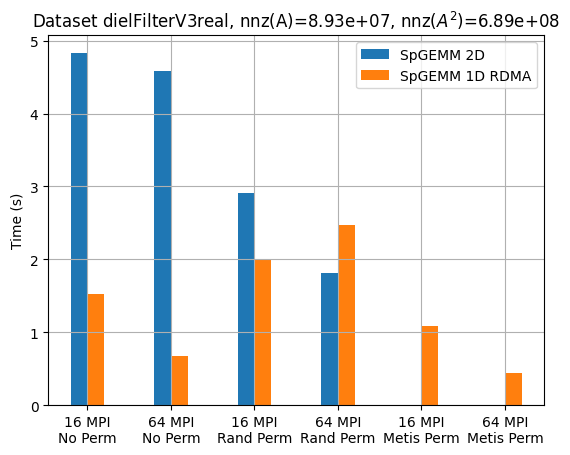

In [3]:
# dataset='cage15'
dataset='dielFilterV3real'
AAtime = {}
AAnnz = {}
fileprefix = ['16mpi_no_perm','64mpi_no_perm',
              '16mpi_random_perm','64mpi_random_perm',
              '16mpi_metis_perm','64mpi_metis_perm']
for mpisetting in fileprefix:
    AAtime[mpisetting] = np.zeros(2)
    AAnnz[mpisetting] = np.zeros(3).astype(np.int64)
    with open(abspath + f"/{dataset}/{dataset}_{mpisetting}.log", 'r') as f:
        while 1:
            line = f.readline()
            if not line:
                break
            # extract AA
            if mpisetting != '16mpi_metis_perm' and mpisetting != '64mpi_metis_perm':
                if line.startswith("Timer|Info: AA_2D"):
                    AAtime[mpisetting][0] = float(line.split(' ')[-1])
                    line = f.readline()
                    AAtime[mpisetting][1] = float(line.split(' ')[-1]) 
                    line = f.readline()
                    AAnnz[mpisetting][0] = int(line.split(' ')[-1])
                    AAnnz[mpisetting][1] = int(line.split(' ')[-1])
                    line = f.readline()
                    AAnnz[mpisetting][2] = int(line.split(' ')[-1])
            else:
                if line.startswith("Timer|Info: AA_1D_CBC"):
                    AAtime[mpisetting][1] = float(line.split(' ')[-1])
AA2Dtime = []
AA1Dtime = []
for x,mpisetting in enumerate(fileprefix):
    if mpisetting != '16mpi_metis_perm' and mpisetting != '64mpi_metis_perm':
        AA2Dtime.append(AAtime[mpisetting][0])
        AA1Dtime.append(AAtime[mpisetting][1])
    else:
        # AA2Dtime.append(0.0)
        AA1Dtime.append(AAtime[mpisetting][1])
plt.figure()
plt.bar(np.arange(len(AA2Dtime))-0.1,AA2Dtime,width=0.2,label='SpGEMM 2D')
plt.bar(np.arange(len(AA1Dtime))+0.1,AA1Dtime,width=0.2,label='SpGEMM 1D RDMA')
plt.grid()
plt.legend()
plt.ylabel("Time (s)")
plt.xticks(np.arange(len(AA1Dtime)),
           ['16 MPI\nNo Perm','64 MPI\nNo Perm',
            '16 MPI\nRand Perm','64 MPI\nRand Perm',
            '16 MPI\nMetis Perm','64 MPI\nMetis Perm'])
mpisetting = '16mpi_no_perm'
plt.title(r"Dataset {}, nnz(A)={:.2e}, nnz($A^2$)={:.2e}".format(dataset,AAnnz[mpisetting][0],AAnnz[mpisetting][2]))
plt.show()

# Multiple dataset View - AA

In [ ]:
dlist = ['mouse_gene','ldoor','dielFilterV3real','cage15','nlpkkt160','HV15R']
ndataset = len(dlist)
nrow = 2
ncol = 3
fig, axes = plt.subplots(nrows=nrow,ncols=ncol, figsize=(20, 13))
for didx, dataset in enumerate(dlist):
    AAtime = {}
    AAnnz = {}
    dr = didx // ncol
    dc = didx % ncol
    fileprefix = ['16mpi_no_perm','64mpi_no_perm',
              '16mpi_random_perm','64mpi_random_perm',
              '16mpi_metis_perm','64mpi_metis_perm']
    for mpisetting in fileprefix:
        AAtime[mpisetting] = np.zeros(2)
        AAnnz[mpisetting] = np.zeros(3).astype(np.int64)
        with open(abspath + f"/{dataset}/{dataset}_{mpisetting}.log", 'r') as f:
            while 1:
                line = f.readline()
                if not line:
                    break
                # extract AA
                if mpisetting != '16mpi_metis_perm' and mpisetting != '64mpi_metis_perm':
                    if line.startswith("Timer|Info: AA_2D"):
                        AAtime[mpisetting][0] = float(line.split(' ')[-1])
                        line = f.readline()
                        AAtime[mpisetting][1] = float(line.split(' ')[-1]) 
                        line = f.readline()
                        AAnnz[mpisetting][0] = int(line.split(' ')[-1])
                        AAnnz[mpisetting][1] = int(line.split(' ')[-1])
                        line = f.readline()
                        AAnnz[mpisetting][2] = int(line.split(' ')[-1])
                else:
                    if line.startswith("Timer|Info: AA_1D_CBC"):
                        AAtime[mpisetting][1] = float(line.split(' ')[-1])
    AA2Dtime = []
    AA1Dtime = []
    for x,mpisetting in enumerate(fileprefix):
        if mpisetting != '16mpi_metis_perm' and mpisetting != '64mpi_metis_perm':
            AA2Dtime.append(AAtime[mpisetting][0])
            AA1Dtime.append(AAtime[mpisetting][1])
        else:
            # AA2Dtime.append(0.0)
            AA1Dtime.append(AAtime[mpisetting][1])
    
    axes[dr,dc].bar(np.arange(len(AA2Dtime))-0.1,AA2Dtime,width=0.2,label='SpGEMM 2D')
    axes[dr,dc].bar(np.arange(len(AA1Dtime))+0.1,AA1Dtime,width=0.2,label='SpGEMM 1D RDMA')
    axes[dr,dc].grid()
    axes[dr,dc].legend()
    axes[dr,dc].set_ylabel("Time (s)")
    axes[dr,dc].set_xticks(
        np.arange(len(AA1Dtime)),
        ['16 MPI\nNo Perm','64 MPI\nNo Perm',
            '16 MPI\nRand Perm','64 MPI\nRand Perm',
            '16 MPI\nMetis Perm','64 MPI\nMetis Perm'])
    mpisetting = '16mpi_no_perm'
    axes[dr,dc].set_title(r"Dataset {}, nnz(A)={:.2e}, nnz($A^2$)={:.2e}".format(dataset,AAnnz[mpisetting][0],AAnnz[mpisetting][2]))
plt.suptitle("$A^2$ Operation")
plt.subplots_adjust(hspace=0.5)
# plt.savefig("Asquare.png",dpi=300,bbox_inches='tight')
plt.show()

# single dataset plot - RTA

In [ ]:
# dataset='cage15'
dataset='dielFilterV3real'
RTAtime = {}
RTAnnz = {}
fileprefix = ['16mpi_no_perm','64mpi_no_perm',
              '16mpi_random_perm','64mpi_random_perm',
              '16mpi_metis_perm','64mpi_metis_perm']
for mpisetting in fileprefix:
    RTAtime[mpisetting] = np.zeros(2)
    RTAnnz[mpisetting] = np.zeros(3).astype(np.int64)
    with open(abspath + f"/{dataset}/{dataset}_{mpisetting}.log", 'r') as f:
        while 1:
            line = f.readline()
            if not line:
                break
            # extract AA
            if line.startswith("Timer|Info: RTA_2D"):
                RTAtime[mpisetting][0] = float(line.split(' ')[-1])
                line = f.readline()
                RTAtime[mpisetting][1] = float(line.split(' ')[-1]) 
                line = f.readline()
                RTAnnz[mpisetting][0] = int(line.split(' ')[-1])
                line = f.readline()
                RTAnnz[mpisetting][1] = int(line.split(' ')[-1])
                line = f.readline()
                RTAnnz[mpisetting][2] = int(line.split(' ')[-1])
RTA2Dtime = []
RTA1Dtime = []
for x,mpisetting in enumerate(fileprefix):
    RTA2Dtime.append(RTAtime[mpisetting][0])
    RTA1Dtime.append(RTAtime[mpisetting][1])
plt.figure()
plt.bar(np.arange(len(RTA2Dtime))-0.1,RTA2Dtime,width=0.2,label='SpGEMM 2D')
plt.bar(np.arange(len(RTA1Dtime))+0.1,RTA1Dtime,width=0.2,label='SpGEMM 1D RDMA')
plt.grid()
plt.legend()
plt.ylabel("Time (s)")
plt.xticks(
    np.arange(len(RTA1Dtime)),
    ['16 MPI\nNo Perm','64 MPI\nNo Perm',
            '16 MPI\nRand Perm','64 MPI\nRand Perm',
            '16 MPI\nMetis Perm','64 MPI\nMetis Perm'])
plt.title("Dataset {}\n nnz($R^T$)={:.2e}, nnz(A)={:.2e}, nnz($R^T$A)={:.2e}"
.format(dataset,RTAnnz[mpisetting][0],RTAnnz[mpisetting][1], RTAnnz[mpisetting][2]))
plt.show()

# multiple dataset plot - RTA

In [ ]:
# dataset='cage15'
# dataset=
dlist = ['mouse_gene','ldoor','dielFilterV3real','cage15','nlpkkt160','HV15R']
ndataset = len(dlist)
nrow = 2
ncol = 3
fig, axes = plt.subplots(nrows=nrow,ncols=ncol, figsize=(20, 13))
for didx, dataset in enumerate(dlist):
    RTAtime = {}
    RTAnnz = {}
    dr = didx // ncol
    dc = didx % ncol
    fileprefix = ['16mpi_no_perm','64mpi_no_perm',
              '16mpi_random_perm','64mpi_random_perm',
              '16mpi_metis_perm','64mpi_metis_perm']
    for mpisetting in fileprefix:
        RTAtime[mpisetting] = np.zeros(2)
        RTAnnz[mpisetting] = np.zeros(3).astype(np.int64)
        with open(abspath + f"/{dataset}/{dataset}_{mpisetting}.log", 'r') as f:
            while 1:
                line = f.readline()
                if not line:
                    break
                # extract AA
                if line.startswith("Timer|Info: RTA_2D"):
                    RTAtime[mpisetting][0] = float(line.split(' ')[-1])
                    line = f.readline()
                    RTAtime[mpisetting][1] = float(line.split(' ')[-1]) 
                    line = f.readline()
                    RTAnnz[mpisetting][0] = int(line.split(' ')[-1])
                    line = f.readline()
                    RTAnnz[mpisetting][1] = int(line.split(' ')[-1])
                    line = f.readline()
                    RTAnnz[mpisetting][2] = int(line.split(' ')[-1])
    RTA2Dtime = []
    RTA1Dtime = []
    for x,mpisetting in enumerate(fileprefix):
        RTA2Dtime.append(RTAtime[mpisetting][0])
        RTA1Dtime.append(RTAtime[mpisetting][1])
    
    axes[dr,dc].bar(np.arange(len(RTA2Dtime))-0.1,RTA2Dtime,width=0.2,label='SpGEMM 2D')
    axes[dr,dc].bar(np.arange(len(RTA1Dtime))+0.1,RTA1Dtime,width=0.2,label='SpGEMM 1D RDMA')
    axes[dr,dc].grid()
    axes[dr,dc].legend()
    axes[dr,dc].set_ylabel("Time (s)")
    axes[dr,dc].set_xticks(
        np.arange(len(RTA1Dtime)),
        ['16 MPI\nNo Perm','64 MPI\nNo Perm',
            '16 MPI\nRand Perm','64 MPI\nRand Perm',
            '16 MPI\nMetis Perm','64 MPI\nMetis Perm'])
    axes[dr,dc].set_title("Dataset {}\n nnz($R^T$)={:.2e}, nnz(A)={:.2e}, nnz($R^T$A)={:.2e}"
.format(dataset,RTAnnz[mpisetting][0],RTAnnz[mpisetting][1], RTAnnz[mpisetting][2]))
plt.suptitle("$R^T$A Operation")
plt.subplots_adjust(hspace=0.5)
plt.savefig("RTA.png",dpi=300,bbox_inches='tight')
plt.show()

# single dataset plot - RTAR

In [ ]:
# dataset='cage15'
dataset='dielFilterV3real'
RTAtime = {}
RTAnnz = {}
fileprefix = ['16mpi_no_perm','64mpi_no_perm',
              '16mpi_random_perm','64mpi_random_perm',
              '16mpi_metis_perm','64mpi_metis_perm']
for mpisetting in fileprefix:
    RTAtime[mpisetting] = np.zeros(3)
    RTAnnz[mpisetting] = np.zeros(3).astype(np.int64)
    with open(abspath + f"/{dataset}/{dataset}_{mpisetting}.log", 'r') as f:
        while 1:
            line = f.readline()
            if not line:
                break
            # extract AA
            if line.startswith("Timer|Info: RTAR_2D"):
                RTAtime[mpisetting][0] = float(line.split(' ')[-1])
                line = f.readline()
                RTAtime[mpisetting][1] = float(line.split(' ')[-1]) 
                line = f.readline()
                RTAnnz[mpisetting][0] = int(line.split(' ')[-1])
                line = f.readline()
                RTAnnz[mpisetting][1] = int(line.split(' ')[-1])
                line = f.readline()
                RTAnnz[mpisetting][2] = int(line.split('=')[-1])
            if line.startswith("Timer|Info: RTAR_1DOP"):
                RTAtime[mpisetting][2] = float(line.split(' ')[-1])
RTA2Dtime = []
RTA1Dtime = []
RTAOPtime = []
for x,mpisetting in enumerate(fileprefix):
    RTA2Dtime.append(RTAtime[mpisetting][0])
    RTA1Dtime.append(RTAtime[mpisetting][1])
    RTAOPtime.append(RTAtime[mpisetting][2])

plt.figure()
plt.bar(np.arange(len(RTA2Dtime))-0.2,RTA2Dtime,width=0.2,label='SpGEMM 2D')
plt.bar(np.arange(len(RTA1Dtime)),RTA1Dtime,width=0.2,label='SpGEMM 1D RDMA')
plt.bar(np.arange(len(RTA1Dtime))+0.2,RTAOPtime,width=0.2,label='SpGEMM 1D RDMA OP')
plt.grid()
plt.legend()
plt.ylabel("Time (s)")
plt.xticks(
    np.arange(len(RTA1Dtime)),
    ['16 MPI\nNo Perm','64 MPI\nNo Perm',
            '16 MPI\nRand Perm','64 MPI\nRand Perm',
            '16 MPI\nMetis Perm','64 MPI\nMetis Perm'])
plt.title("Dataset {}\n nnz($R^TA$)={:.2e}, nnz(R)={:.2e}, nnz($R^T$AR)={:.2e}"
.format(dataset,RTAnnz[mpisetting][0],RTAnnz[mpisetting][1], RTAnnz[mpisetting][2]))
plt.show()

# multiple dataset plot - RTAR

In [ ]:
# dataset='cage15'
# dataset=
dlist = ['mouse_gene','ldoor','dielFilterV3real','cage15','nlpkkt160','HV15R']
ndataset = len(dlist)
nrow = 2
ncol = 3
fig, axes = plt.subplots(nrows=nrow,ncols=ncol, figsize=(20, 13))
for didx, dataset in enumerate(dlist):
    RTAtime = {}
    RTAnnz = {}
    dr = didx // ncol
    dc = didx % ncol
    fileprefix = ['16mpi_no_perm','64mpi_no_perm',
              '16mpi_random_perm','64mpi_random_perm',
              '16mpi_metis_perm','64mpi_metis_perm']
    for mpisetting in fileprefix:
        RTAtime[mpisetting] = np.zeros(3)
        RTAnnz[mpisetting] = np.zeros(3).astype(np.int64)
        with open(abspath + f"/{dataset}/{dataset}_{mpisetting}.log", 'r') as f:
            while 1:
                line = f.readline()
                if not line:
                    break
                # extract AA
                if line.startswith("Timer|Info: RTAR_2D"):
                    RTAtime[mpisetting][0] = float(line.split(' ')[-1])
                    line = f.readline()
                    RTAtime[mpisetting][1] = float(line.split(' ')[-1]) 
                    line = f.readline()
                    RTAnnz[mpisetting][0] = int(line.split(' ')[-1])
                    line = f.readline()
                    RTAnnz[mpisetting][1] = int(line.split(' ')[-1])
                    line = f.readline()
                    RTAnnz[mpisetting][2] = int(line.split('=')[-1])
                if line.startswith("Timer|Info: RTAR_1DOP"):
                    RTAtime[mpisetting][2] = float(line.split(' ')[-1])
    RTA2Dtime = []
    RTA1Dtime = []
    RTAOPtime = []
    for x,mpisetting in enumerate(fileprefix):
        RTA2Dtime.append(RTAtime[mpisetting][0])
        RTA1Dtime.append(RTAtime[mpisetting][1])
        RTAOPtime.append(RTAtime[mpisetting][2])
    
    axes[dr,dc].bar(np.arange(len(RTA2Dtime))-0.2,RTA2Dtime,width=0.2,label='SpGEMM 2D')
    axes[dr,dc].bar(np.arange(len(RTA1Dtime)),RTA1Dtime,width=0.2,label='SpGEMM 1D RDMA')
    axes[dr,dc].bar(np.arange(len(RTA1Dtime))+0.2,RTAOPtime,width=0.2,label='SpGEMM 1D RDMA OP')
    axes[dr,dc].grid()
    axes[dr,dc].legend()
    axes[dr,dc].set_ylabel("Time (s)")
    axes[dr,dc].set_xticks(
        np.arange(len(RTA1Dtime)),
        ['16 MPI\nNo Perm','64 MPI\nNo Perm',
            '16 MPI\nRand Perm','64 MPI\nRand Perm',
            '16 MPI\nMetis Perm','64 MPI\nMetis Perm'])
    axes[dr,dc].set_title("Dataset {}\n nnz($R^TA$)={:.2e}, nnz(R)={:.2e}, nnz($R^T$AR)={:.2e}"
.format(dataset,RTAnnz[mpisetting][0],RTAnnz[mpisetting][1], RTAnnz[mpisetting][2]))
plt.suptitle("$R^T$AR Operation")
plt.subplots_adjust(hspace=0.4)
plt.savefig("RTAR.png",dpi=300,bbox_inches='tight')
plt.show()